## ***SEISMIC VISTA***

### **EXPLORATORY DATA ANALYSIS (EDA)**

#### **1. Data Collection**

In [4]:
import pandas as pd
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings("ignore")

In [5]:
conn = sqlite3.connect("earthquakes.db")

In [6]:
da = pd.read_sql_query("SELECT * FROM earthquake_data", conn)
conn.close()

**Show Top 5 Records**

In [7]:
da.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2017-06-29 23:42:45.590000+00:00,51.3421,-174.5053,19.11,2.90,ml,NaN,269.0,0.9660,0.19,...,2023-08-08T20:13:41.259Z,"97 km SSW of Atka, Alaska",earthquake,8.1,20.50,NaN,NaN,reviewed,us,ak
1,2017-06-29 23:37:50.810000+00:00,0.4048,-17.6466,10.00,4.70,mb,NaN,169.0,13.9150,0.22,...,2017-09-27T02:03:19.040Z,north of Ascension Island,earthquake,13.0,1.90,0.143,15.0,reviewed,us,us
2,2017-06-29 23:37:21.180000+00:00,51.4895,-176.3379,35.00,2.50,ml,NaN,210.0,0.4480,0.32,...,2023-08-08T20:13:35.781Z,"47 km SSE of Adak, Alaska",earthquake,4.5,2.00,NaN,NaN,reviewed,us,ak
3,2017-06-29 23:29:21.930000+00:00,14.0962,-93.1814,10.00,4.10,mb,NaN,182.0,1.1990,1.43,...,2017-09-27T02:03:19.040Z,"107 km SW of Puerto Madero, Mexico",earthquake,6.0,2.00,0.151,12.0,reviewed,us,us
4,2017-06-29 23:26:51.580000+00:00,19.1678,-67.9361,85.00,2.96,md,4.0,234.0,0.7911,0.42,...,2017-07-02T00:40:08.360Z,"81 km NE of Punta Cana, Dominican Republic",earthquake,13.4,14.68,0.190,3.0,reviewed,pr,pr


**Show Last 5 Records**

In [8]:
da.tail()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
241645,2026-01-01 01:59:15.761000+00:00,60.4491,-139.7327,5.000,2.9,ml,23.0,91.0,0.439,0.98,...,2026-01-24T00:04:04.040Z,"100 km N of Yakutat, Alaska",earthquake,2.43,1.978,0.052,48.0,reviewed,us,us
241646,2026-01-01 01:53:01.809000+00:00,-45.6117,96.3592,10.000,6.0,mww,67.0,45.0,17.240,0.66,...,2026-01-24T00:05:12.232Z,southeast Indian Ridge,earthquake,10.14,1.839,0.052,35.0,reviewed,us,us
241647,2026-01-01 01:25:20.926000+00:00,-56.1770,-28.1811,118.207,4.5,mb,22.0,178.0,5.119,1.00,...,2026-01-23T23:39:34.040Z,South Sandwich Islands region,earthquake,14.01,10.633,0.118,21.0,reviewed,us,us
241648,2026-01-01 00:46:26.988000+00:00,56.3007,-148.7003,10.000,3.9,mb,44.0,144.0,2.590,0.57,...,2026-01-30T06:04:28.040Z,"262 km SE of Chiniak, Alaska",earthquake,6.92,1.939,0.137,14.0,reviewed,us,us
241649,2026-01-01 00:03:02.325000+00:00,60.4463,-139.6346,5.000,3.2,ml,37.0,78.0,0.467,0.81,...,2026-01-30T05:56:01.040Z,"100 km N of Yakutat, Alaska",earthquake,3.28,1.961,0.036,104.0,reviewed,us,us


**Shape of the Dataset**

In [9]:
da.shape

(241650, 22)

**Information About The Entire Database**

In [10]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241650 entries, 0 to 241649
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   time             241650 non-null  object 
 1   latitude         241650 non-null  float64
 2   longitude        241650 non-null  float64
 3   depth            241650 non-null  float64
 4   mag              241650 non-null  float64
 5   magType          241649 non-null  object 
 6   nst              132817 non-null  float64
 7   gap              225408 non-null  float64
 8   dmin             218262 non-null  float64
 9   rms              241563 non-null  float64
 10  net              241650 non-null  object 
 11  id               241650 non-null  object 
 12  updated          241650 non-null  object 
 13  place            241650 non-null  object 
 14  type             241650 non-null  object 
 15  horizontalError  223010 non-null  float64
 16  depthError       241633 non-null  floa

**Check statistics of data set**

In [11]:
da.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,241650.000000,241650.000000,241650.000000,241650.000000,132817.000000,225408.000000,218262.000000,241563.000000,223010.00000,241633.000000,219903.000000,221111.000000
mean,20.220031,-35.119542,58.068364,3.790172,37.947567,131.825385,2.448548,0.590779,6.38560,4.617900,0.136320,33.833997
std,30.577619,125.573073,108.849982,0.873826,34.978176,73.347085,4.032996,0.326128,4.40954,33.384328,0.145226,50.823652
min,-82.883700,-179.999700,-3.740000,0.700000,0.000000,7.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,-3.547925,-152.417400,10.000000,2.900000,17.000000,72.000000,0.396000,0.350000,2.75000,1.734000,0.078000,10.000000
50%,19.419800,-68.984000,13.690000,4.100000,26.000000,117.000000,1.206000,0.600000,6.38000,2.000000,0.115000,18.000000
75%,48.611267,120.529450,52.655250,4.500000,47.000000,186.000000,2.830000,0.800000,9.30000,6.900000,0.162000,36.000000
max,87.386000,179.999400,681.238000,8.800000,619.000000,359.000000,127.420000,46.240000,99.00000,15982.200000,5.670000,1027.000000


In [12]:
da.describe(include="all")

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
count,241650,241650.000000,241650.000000,241650.000000,241650.000000,241649,132817.000000,225408.000000,218262.000000,241563.000000,...,241650,241650,241650,223010.00000,241633.000000,219903.000000,221111.000000,241650,241650,241650
unique,241638,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,...,85076,107770,16,NaN,NaN,NaN,NaN,2,30,33
top,2019-01-22 00:04:51.100000+00:00,NaN,NaN,NaN,NaN,mb,NaN,NaN,NaN,NaN,...,2025-10-17T22:51:42.040Z,South Sandwich Islands region,earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
freq,2,NaN,NaN,NaN,NaN,118073,NaN,NaN,NaN,NaN,...,1775,3870,239474,NaN,NaN,NaN,NaN,239272,169921,166815
mean,NaN,20.220031,-35.119542,58.068364,3.790172,NaN,37.947567,131.825385,2.448548,0.590779,...,NaN,NaN,NaN,6.38560,4.617900,0.136320,33.833997,NaN,NaN,NaN
std,NaN,30.577619,125.573073,108.849982,0.873826,NaN,34.978176,73.347085,4.032996,0.326128,...,NaN,NaN,NaN,4.40954,33.384328,0.145226,50.823652,NaN,NaN,NaN
min,NaN,-82.883700,-179.999700,-3.740000,0.700000,NaN,0.000000,7.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.00000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,-3.547925,-152.417400,10.000000,2.900000,NaN,17.000000,72.000000,0.396000,0.350000,...,NaN,NaN,NaN,2.75000,1.734000,0.078000,10.000000,NaN,NaN,NaN
50%,NaN,19.419800,-68.984000,13.690000,4.100000,NaN,26.000000,117.000000,1.206000,0.600000,...,NaN,NaN,NaN,6.38000,2.000000,0.115000,18.000000,NaN,NaN,NaN
75%,NaN,48.611267,120.529450,52.655250,4.500000,NaN,47.000000,186.000000,2.830000,0.800000,...,NaN,NaN,NaN,9.30000,6.900000,0.162000,36.000000,NaN,NaN,NaN


### **2. Missing Values Analysis**

**2.1 Check Missing values**

In [13]:
da.isnull()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,True,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241645,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
241646,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
241647,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
241648,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**2.2 Check if Any Missing Values Exist in Columns**

In [14]:
da.isnull().any()

time               False
latitude           False
longitude          False
depth              False
mag                False
magType             True
nst                 True
gap                 True
dmin                True
rms                 True
net                False
id                 False
updated            False
place              False
type               False
horizontalError     True
depthError          True
magError            True
magNst              True
status             False
locationSource     False
magSource          False
dtype: bool

**2.3 Count of Missing Values per Column**

In [15]:
da.isnull().sum()

time                    0
latitude                0
longitude               0
depth                   0
mag                     0
magType                 1
nst                108833
gap                 16242
dmin                23388
rms                    87
net                     0
id                      0
updated                 0
place                   0
type                    0
horizontalError     18640
depthError             17
magError            21747
magNst              20539
status                  0
locationSource          0
magSource               0
dtype: int64

**2.4 Percentage of Missing Values per Column**

In [16]:
da.isnull().mean()*100

time                0.000000
latitude            0.000000
longitude           0.000000
depth               0.000000
mag                 0.000000
magType             0.000414
nst                45.037451
gap                 6.721291
dmin                9.678461
rms                 0.036002
net                 0.000000
id                  0.000000
updated             0.000000
place               0.000000
type                0.000000
horizontalError     7.713635
depthError          0.007035
magError            8.999379
magNst              8.499483
status              0.000000
locationSource      0.000000
magSource           0.000000
dtype: float64

In [17]:
da.drop(columns = ["nst","gap","dmin","net","id","updated","type","horizontalError","magError","magNst","status","locationSource","magSource"], inplace = True)

In [18]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241650 entries, 0 to 241649
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   time        241650 non-null  object 
 1   latitude    241650 non-null  float64
 2   longitude   241650 non-null  float64
 3   depth       241650 non-null  float64
 4   mag         241650 non-null  float64
 5   magType     241649 non-null  object 
 6   rms         241563 non-null  float64
 7   place       241650 non-null  object 
 8   depthError  241633 non-null  float64
dtypes: float64(6), object(3)
memory usage: 16.6+ MB


**2.6 Filling Missing Values in Categorical Columns**

In [19]:
da["magType"] = da["magType"].fillna(da["magType"].mode()[0])
da["rms"] = da["rms"].fillna(da["rms"].median())
da["depthError"] = da["depthError"].fillna(da["depthError"].median())

In [20]:
da.isnull().sum()

time          0
latitude      0
longitude     0
depth         0
mag           0
magType       0
rms           0
place         0
depthError    0
dtype: int64

**Insights**
- After filling missing values, all columns show 0 missing values. The dataset is now complete and ready for EDA and model training.

**2.7 Convert time column to datetime format and extract temporal features**

In [21]:
# Convert text to proper datetime format
da["time"] = pd.to_datetime(da["time"], format="mixed", utc=True, errors="coerce")

da["year"] = da["time"].dt.year
da["month"] = da["time"].dt.month
da['day_of_week'] = da['time'].dt.dayofweek
da['hour'] = da['time'].dt.hour

In [22]:
print(list(da.columns))

['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'rms', 'place', 'depthError', 'year', 'month', 'day_of_week', 'hour']


In [23]:
da.drop(columns=['time'], inplace=True)
print(list(da.columns))

['latitude', 'longitude', 'depth', 'mag', 'magType', 'rms', 'place', 'depthError', 'year', 'month', 'day_of_week', 'hour']


**2.8 Extract region and distance from 'place'**

In [24]:
# "97 km SSW of Atka, Alaska" → "Alaska"
da['region'] = da['place'].str.split(',').str[-1].str.strip()

# "97 km SSW of Atka, Alaska" → 97.0
da['dist_km'] = da['place'].str.extract(r'(\d+)\s*km')[0].astype(float)
da['dist_km'].fillna(0, inplace=True)

da.drop(columns=["place"], inplace=True)

In [25]:
print(list(da.columns))

['latitude', 'longitude', 'depth', 'mag', 'magType', 'rms', 'depthError', 'year', 'month', 'day_of_week', 'hour', 'region', 'dist_km']


In [26]:
da.head(1)

,latitude,longitude,depth,mag,magType,rms,depthError,year,month,day_of_week,hour,region,dist_km
0,51.3421,-174.5053,19.11,2.9,ml,0.19,20.5,2017,6,3,23,Alaska,97.0


**2.9 Create earthquake magnitude classes based on magnitude values**

In [27]:
def classify_mag(mag):
    if mag < 3.0:
        return "Micro"
    elif mag < 4.0:
        return "Minor"
    elif mag < 5.0:
        return "Light"
    elif mag < 6.0:
        return "Moderate"
    elif mag < 7.0:
        return "Strong"
    elif mag < 8.0:
        return "Major"
    else:
        return "Great"

da["class"] = da["mag"].apply(classify_mag)

**2.10 Assign earthquake risk levels based on magnitude**

In [28]:
def risk_level(mag):
    if mag < 5.0:
        return "Low Risk"
    if mag < 6.0:
        return "Moderate Risk"
    if mag < 7.0:
        return "High Risk"
    else:
        return "Critical"

da['risk_level'] = da['mag'].apply(risk_level)

In [29]:
da.head(5)

,latitude,longitude,depth,mag,magType,rms,depthError,year,month,day_of_week,hour,region,dist_km,class,risk_level
0,51.3421,-174.5053,19.11,2.90,ml,0.19,20.50,2017,6,3,23,Alaska,97.0,Micro,Low Risk
1,0.4048,-17.6466,10.00,4.70,mb,0.22,1.90,2017,6,3,23,north of Ascension Island,0.0,Light,Low Risk
2,51.4895,-176.3379,35.00,2.50,ml,0.32,2.00,2017,6,3,23,Alaska,47.0,Micro,Low Risk
3,14.0962,-93.1814,10.00,4.10,mb,1.43,2.00,2017,6,3,23,Mexico,107.0,Light,Low Risk
4,19.1678,-67.9361,85.00,2.96,md,0.42,14.68,2017,6,3,23,Dominican Republic,81.0,Micro,Low Risk


### **3. Data Visualization**

**3.1 Import Seaborn, Matplotlib**

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

***3.1.1 Bar Chart***

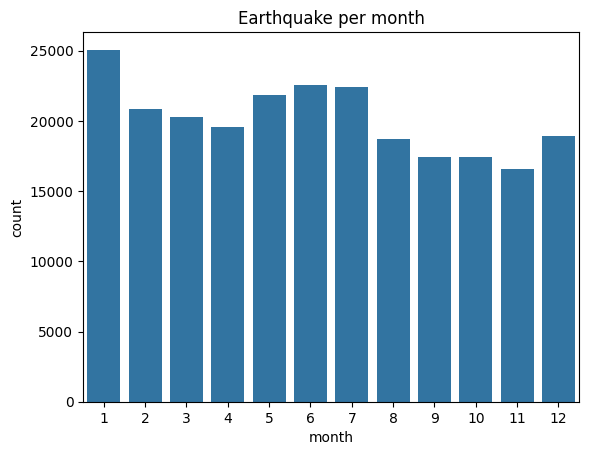

In [31]:
sns.countplot(x="month", data=da)
plt.title("Earthquake per month")
plt.xlabel("month")
plt.ylabel("count")
plt.show()

***3.1.2 Heatmap***

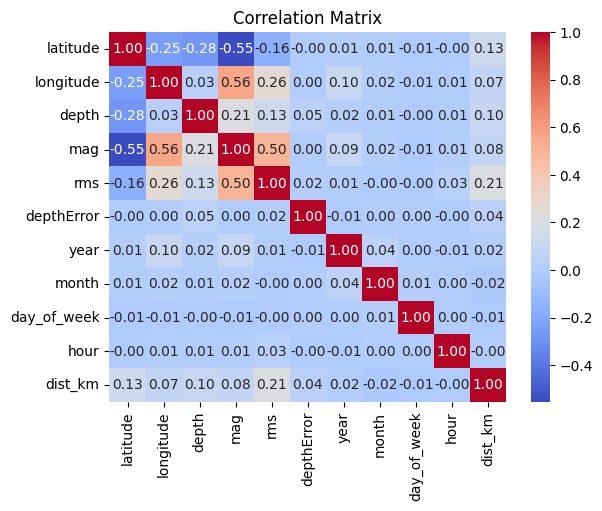

In [32]:
sns.heatmap(da.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
#fmt=".2f" -  Formats numbers to 2 decimal places.
plt.title("Correlation Matrix")
plt.show()

### **MODEL TRAINING**

In [33]:
da.head(5)

,latitude,longitude,depth,mag,magType,rms,depthError,year,month,day_of_week,hour,region,dist_km,class,risk_level
0,51.3421,-174.5053,19.11,2.90,ml,0.19,20.50,2017,6,3,23,Alaska,97.0,Micro,Low Risk
1,0.4048,-17.6466,10.00,4.70,mb,0.22,1.90,2017,6,3,23,north of Ascension Island,0.0,Light,Low Risk
2,51.4895,-176.3379,35.00,2.50,ml,0.32,2.00,2017,6,3,23,Alaska,47.0,Micro,Low Risk
3,14.0962,-93.1814,10.00,4.10,mb,1.43,2.00,2017,6,3,23,Mexico,107.0,Light,Low Risk
4,19.1678,-67.9361,85.00,2.96,md,0.42,14.68,2017,6,3,23,Dominican Republic,81.0,Micro,Low Risk


In [52]:
from sklearn.preprocessing import LabelEncoder

le_magType = LabelEncoder()
le_region  = LabelEncoder()
le_class   = LabelEncoder()
le_risk_level = LabelEncoder()

da['magType'] = le_magType.fit_transform(da['magType'])
da['region']  = le_region.fit_transform(da['region'])
da['class']   = le_class.fit_transform(da['class'])
da['risk_level'] = le_risk_level.fit_transform(da['risk_level'])

In [39]:
da.head(5)

,latitude,longitude,depth,mag,magType,rms,depthError,year,month,day_of_week,hour,region,dist_km,class,risk_level
0,51.3421,-174.5053,19.11,2.90,7,0.19,20.50,2017,6,3,23,17,97.0,3,2
1,0.4048,-17.6466,10.00,4.70,3,0.22,1.90,2017,6,3,23,521,0.0,1,2
2,51.4895,-176.3379,35.00,2.50,7,0.32,2.00,2017,6,3,23,17,47.0,3,2
3,14.0962,-93.1814,10.00,4.10,3,1.43,2.00,2017,6,3,23,257,107.0,1,2
4,19.1678,-67.9361,85.00,2.96,5,0.42,14.68,2017,6,3,23,114,81.0,3,2


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

In [41]:
#Features and Target
X = da[["mag","depth", "latitude", "longitude","magType"]]
Y = da["risk_level"]

#Train-Test-Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train,Y_train)
y_pred_lr = lr_model.predict(X_test)

#Random Forest Classifier
rfc_model = RandomForestClassifier(n_estimators=100)
rfc_model.fit(X_train,Y_train)
y_pred_rfc = rfc_model.predict(X_test)

#Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier()
gbc_model.fit(X_train,Y_train)
y_pred_gbc = gbc_model.predict(X_test)

#Decision Tree Classifier
dtc_model = DecisionTreeClassifier()
dtc_model.fit(X_train,Y_train)
y_pred_dtc = dtc_model.predict(X_test)

#XGBoost
xg_model = XGBClassifier(eval_metric='mlogloss')
xg_model.fit(X_train,Y_train)
y_pred_xg = xg_model.predict(X_test)

In [54]:
print("LogisticRegression")
print("accuracy_score:", accuracy_score(Y_test,y_pred_lr))
print("f1_score:",f1_score(Y_test,y_pred_lr, average='weighted'))
print("------")

print("RandomForestClassifier")
print("accuracy_score:", accuracy_score(Y_test,y_pred_rfc))
print("f1_score:",f1_score(Y_test,y_pred_rfc, average='weighted'))
print("------")

print("GradientBoostingClassifier")
print("accuracy_score:", accuracy_score(Y_test,y_pred_gbc))
print("f1_score:",f1_score(Y_test,y_pred_gbc, average='weighted'))
print("------")

print("DecisionTreeClassifier")
print("accuracy_score:", accuracy_score(Y_test,y_pred_dtc))
print("f1_score:",f1_score(Y_test,y_pred_dtc, average='weighted'))
print("------")

print("XGBClassifier")
print("accuracy_score:", accuracy_score(Y_test,y_pred_xg))
print("f1_score:",f1_score(Y_test,y_pred_xg, average='weighted'))

LogisticRegression
accuracy_score: 0.9418787502586385
f1_score: 0.9317702479328575
------
RandomForestClassifier
accuracy_score: 1.0
f1_score: 1.0
------
GradientBoostingClassifier
accuracy_score: 1.0
f1_score: 1.0
------
DecisionTreeClassifier
accuracy_score: 1.0
f1_score: 1.0
------
XGBClassifier
accuracy_score: 0.9994206496999793
f1_score: 0.9993933941727805


In [55]:
model_results = {
    "LogisticRegression":{
        "accuracy_score": 0.9418787502586385,
        "f1_score": 0.9317702479328575
    },

    "RandomForestClassifier":{
        "accuracy_score": 1.0,
        "f1_score": 1.0
    },

    "GradientBoostingClassifier":{
        "accuracy_score": 1.0,
        "f1_score": 1.0
    },

    "DecisionTreeClassifier":{
        "accuracy_score": 1.0,
        "f1_score": 1.0
    },

    "XGBClassifier":{
        "accuracy_score": 0.9994206496999793,
        "f1_score": 0.9993933941727805
    }
}

In [56]:
da_results = pd.DataFrame.from_dict(model_results, orient="index")
da_results = da_results.reset_index().rename(columns={'index': 'Model'})
da_results

,Model,accuracy_score,f1_score
0,LogisticRegression,0.941879,0.931770
1,RandomForestClassifier,1.000000,1.000000
2,GradientBoostingClassifier,1.000000,1.000000
3,DecisionTreeClassifier,1.000000,1.000000
4,XGBClassifier,0.999421,0.999393


In [57]:
da_results = da_results.sort_values(by="f1_score", ascending = False)
da_results

,Model,accuracy_score,f1_score
1,RandomForestClassifier,1.000000,1.000000
3,DecisionTreeClassifier,1.000000,1.000000
2,GradientBoostingClassifier,1.000000,1.000000
4,XGBClassifier,0.999421,0.999393
0,LogisticRegression,0.941879,0.931770


In [58]:
best_model = da_results.iloc[0]["Model"]
print("Best Model:", best_model)

Best Model: RandomForestClassifier


In [59]:
model_objects = {
    "LogisticRegression"        : lr_model,
    "RandomForestClassifier"    : rfc_model,
    "GradientBoostingClassifier": gbc_model,
    "DecisionTreeClassifier"    : dtc_model,
    "XGBClassifier"             : xg_model,
}

best_model  = da_results.iloc[0]["Model"]
best_model_object = model_objects[best_model]
best_model_object

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
import joblib
joblib.dump(best_model_object, "Risk_Predictor_model.pkl")

['Risk_Predictor_model.pkl']